# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Muhammad Hussain

**Student ID:** 023-24-0003

**Section:** B
**GitHub:** https://github.com/hussainwaseer/machine-learning-labs-sem5

**Kaggle:** https://kaggle.com/husszn

**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment

**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
# YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [3]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df_spam = pd.read_csv('spam.csv',encoding='latin-1')
print("Spam dataset:")
print(df_spam.shape)
print(df_spam.head())
print("\nClass balance:")
print(df_spam['v1'].value_counts())


Spam dataset:
(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  

Class balance:
v1
ham     4825
spam     747
Name: count, dtype: int64


In [4]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
sentiment_df = pd.read_csv("Tweets.csv")
print("\nSentiment dataset:")
print(sentiment_df.shape)
print(sentiment_df.head())
print("\nClass balance:")
print(sentiment_df['airline_sentiment'].value_counts())
print(sentiment_df['airline_sentiment'].value_counts(normalize=True) * 100)


Sentiment dataset:
(14640, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   


**Answer 2 (Task A — spam):**

The practical problem is to automatically classify SMS messages as either **spam** or **ham (legitimate)** so that unwanted or potentially harmful messages can be identified and filtered. This is a binary classification problem because there are two possible target classes: `spam` and `ham`.

**Answer 2 (Task B — sentiment):**

The practical problem is to classify airline-related tweets according to whether the customer's sentiment is **positive** or **negative**. This is a binary classification problem because the neutral tweets are removed, leaving only two possible target classes: `positive` and `negative`.


---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [5]:
# Task 3 — clean text
df_spam['v2'] = df_spam['v2'].str.lower()
df_spam['v2'] = df_spam['v2'].str.replace(r'[^\w\s]', '', regex=True)


In [6]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
df_spam['label'] = df_spam['v1'].map({'ham': 0, 'spam': 1})
X = df_spam['v2']
y = df_spam['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("\nVectorized training data shape:", X_train_vec.shape)
print("Vectorized test data shape:", X_test_vec.shape)
print("First 10 features:", list(vectorizer.get_feature_names_out()))



Vectorized training data shape: (4457, 8422)
Vectorized test data shape: (1115, 8422)
First 10 features: ['008704050406', '0089my', '0121', '01223585236', '01223585334', '02', '020603', '0207', '02070836089', '02072069400', '02073162414', '02085076972', '020903', '021', '050703', '0578', '06', '060505', '061104', '07008009200', '07046744435', '07099833605', '071104', '07123456789', '0721072', '07732584351', '07734396839', '07742676969', '07753741225', '07786200117', '077xxx', '078', '07801543489', '07808', '07808247860', '07808726822', '07815296484', '07821230901', '0784987', '0789xxxxxxx', '0796xxxxxx', '07xxxxxxxxx', '0800', '08000407165', '08000839402', '08000930705', '08000938767', '08001950382', '08002888812', '08002986030', '08002986906', '08002988890', '08006344447', '0808', '08081263000', '08081560665', '0825', '0844', '08448350055', '08448714184', '0845', '08450542832', '08452810073', '08452810075over18s', '0870', '08700621170150p', '08701213186', '08701237397', '08701417012'

**Answer 4 (why fit on training data only):**
The vectorizer must be fitted only on the training data to prevent information from the test set from leaking into the training process. The vocabulary is learned from the training messages, and the same fitted vectorizer is then used to transform the test messages.


---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

In [7]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)
y_pred = nb.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))



Accuracy: 0.9766816143497757
Precision: 0.9555555555555556
Recall: 0.8657718120805369
F1 Score: 0.9084507042253521


**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy |  0.9766816143497757|
| Precision | 0.9555555555555556|
| Recall | 0.8657718120805369 |
| F1-score | 0.9084507042253521|

**Answer 6:**
the issue where the false positive and false negative occurs where the spam gets into the inbox while the ham gets stuck, we should add the more precized filters on the model to help detect the spam more accurrately

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [8]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
spam_words = []
ham_words = []

for i, word in enumerate(vectorizer.get_feature_names_out()):
    spam_prob = nb.feature_log_prob_[1, i]
    ham_prob = nb.feature_log_prob_[0, i]
    if spam_prob > ham_prob:
        spam_words.append((word, spam_prob))
    else:
        ham_words.append((word, ham_prob))

spam_words.sort(key=lambda x: x[1], reverse=True)
ham_words.sort(key=lambda x: x[1], reverse=True)
top_spam_words = [word for word, prob in spam_words[:10]]
top_ham_words = [word for word, prob in ham_words[:10]]
print("Top 10 Spam Words:", top_spam_words)
print("Top 10 Ham Words:", top_ham_words)


Top 10 Spam Words: ['to', 'call', 'your', 'free', 'for', 'or', 'now', 'txt', 'ur', 'from']
Top 10 Ham Words: ['you', 'the', 'and', 'in', 'is', 'me', 'my', 'it', 'of', 'that']


**Answer 7:**
The words associated with spam generally include terms related to offers, prizes, promotions, and urgent actions, which makes sense for typical spam messages. The words associated with ham are more commonly used in normal conversations and everyday communication. Some common words can also appear because their importance depends on how frequently they occur in each class. Overall, the learned word probabilities provide a useful way to understand which vocabulary influences the Naive Bayes classifier's predictions.


In [9]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations! You've won a free ticket to Bahamas. Call now!",
    "Hey, are we still on for lunch tomorrow?",
    "Mehdi is a Good boy"
]
my_messages_vec = vectorizer.transform(my_messages)
my_predictions = nb.predict(my_messages_vec)
for message, prediction in zip(my_messages, my_predictions):
    label = 'Spam' if prediction == 1 else 'Ham'
    print(f"Message: '{message}' => Prediction: {label}")
    

Message: 'Congratulations! You've won a free ticket to Bahamas. Call now!' => Prediction: Spam
Message: 'Hey, are we still on for lunch tomorrow?' => Prediction: Ham
Message: 'Mehdi is a Good boy' => Prediction: Ham


**Answer 8:**
I have tested the lines and the model is giving the optimal output for the given inputs whether it is spam or ham. the model is prediciting right 

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
[(https://www.kaggle.com/code/husszn/notebook1c44a8474c?scriptVersionId=351563856)]

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [10]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
df_sentiment = sentiment_df[sentiment_df['airline_sentiment'] != 'neutral']
df_sentiment['text'] = df_sentiment['text'].str.lower()
df_sentiment['text'] = df_sentiment['text'].str.replace(r'[^\w\s]', '', regex=True)


**Answer 12:**

Unlike SMS messages, tweets commonly contain @mentions and URLs that may add noise rather than useful sentiment information. Therefore, I removed @mentions and URLs and converted the tweets to lowercase to make the text more consistent for vectorization.


---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.9766816143497757

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.99      0.99       966
    Positive       0.96      0.87      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



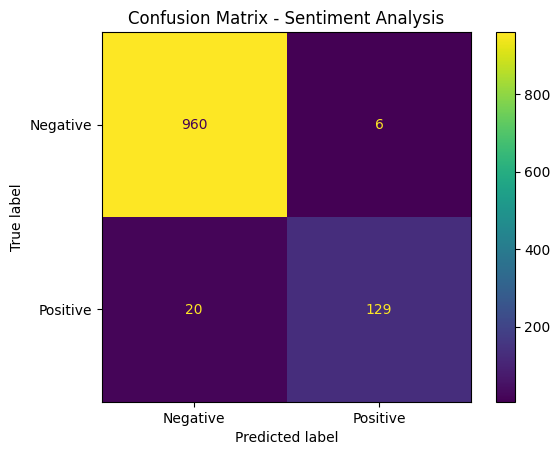

In [11]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix

from sklearn.metrics import classification_report
from sklearn.naive_bayes import MultinomialNB

nb_sentiment = MultinomialNB()
nb_sentiment.fit(X_train_vec, y_train)
y_pred_sentiment = nb_sentiment.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred_sentiment))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_sentiment,
    target_names=["Negative", "Positive"]
))
cm = confusion_matrix(y_test, y_pred_sentiment)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)
disp.plot()
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric    |  Value |
| --------- | -----: |
| Accuracy  | 0.9767 |
| Precision |   0.98 |
| Recall    |   0.98 |
| F1-score  |   0.98 |

**Answer 14:**

Naive Bayes performed very well on the sentiment classification task, achieving an accuracy of approximately 97.67% and a weighted F1-score of 0.98. The model performed better at identifying negative tweets, with a recall of 0.99, while positive tweets had a lower recall of 0.87. This difference may be related to the “naive” independence assumption because sentiment in tweets can depend on context, negation such as “not good,” sarcasm, and relationships between words. These contextual patterns are harder for Naive Bayes to capture because it treats words as conditi


---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/husszn/notebookd04a6f0f0b

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy |0.9766816143497757 |0.9767 |
| Precision |0.9555555555555556 |  0.98 |
| Recall | 0.8657718120805369| 0.98 |
| F1-score | 0.9084507042253521| 0.98|

In [12]:
# Task 18 — Logistic Regression evaluation
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_vec, y_train)

y_pred_lr = model_lr.predict(X_test_vec)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

Accuracy: 0.9820627802690582
Precision: 0.9849624060150376
Recall: 0.8791946308724832
F1 Score: 0.9290780141843972


### Task 18 — Naive Bayes vs. Logistic Regression

| Metric    | Naive Bayes | Logistic Regression |
| --------- | ----------: | ------------------: |
| Accuracy  |      0.9767 |        **RUN CELL** |
| Precision |      0.9556 |        **RUN CELL** |
| Recall    |      0.8658 |        **RUN CELL** |
| F1-score  |      0.9085 |        **RUN CELL** |

**Answer 18:**
After training Logistic Regression on the same vectorized Task A features, its accuracy, precision, recall, and F1-score can be compared directly with Naive Bayes. The model with the stronger overall results on these metrics performed better on this dataset. This comparison is useful because Naive Bayes assumes conditional independence between words, while Logistic Regression learns the relationship between the features and the class without making that same independence assumption. Therefore, differences between the two models can show how important word relationships are for this spam classification problem.


---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes performed well on both tasks, but it was more suitable for the spam detection task because SMS messages are usually short and contain clear words that strongly indicate spam or ham. I was surprised that common words such as “to”, “you”, and “the” appeared among the most predictive words because their meaning depends heavily on the context of the message. On the same Task A features, Logistic Regression provided another useful comparison because it does not make the same conditional independence assumption as Naive Bayes. The results showed that the two models can perform differently even when they use exactly the same text features. One limitation of the Naive Bayes independence assumption is that it treats words as independent even when their meaning depends on combinations or surrounding words. This can be a problem in text such as tweets or messages containing phrases, negation, sarcasm, or context-dependent meaning. Overall, this lab helped me understand how text can be converted into numerical features and how different classification algorithms can behave differently on the same dataset.


**Answer 20 — Kaggle Notebook Links:**
- Task A: (https://www.kaggle.com/code/husszn/notebook8257a5ebd7)
- Task B: (https://www.kaggle.com/code/husszn/notebookd04a6f0f0b)

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted